In [ ]:
!pip install grad-cam

In [ ]:
import os

import random
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, ResNet18_Weights

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
import tensorflow as tf

In [ ]:
from glob import glob

In [ ]:
# настройка GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f" Обнаружено GPU: {len(gpus)} устройств")
    except RuntimeError as e:
        print(f" Ошибка настройки GPU: {e}")
else:
    print(" GPU не обнаружены, будет использоваться CPU")

 Обнаружено GPU: 1 устройств


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = '/content/drive/MyDrive/dataset/train'
test_dir = '/content/drive/MyDrive/dataset/test'

In [ ]:
# Сбор путей и меток
data = []
for label, class_name in enumerate(["tumor", "cancer", "aneurysm"]):
    for img_name in os.listdir(f"/content/drive/MyDrive/dataset/train/{class_name}"):
        # print(img_name)
        data.append({"path": f"/content/drive/MyDrive/dataset/train/{class_name}/{img_name}", "label": label})

df = pd.DataFrame(data)

In [ ]:
df

,path,label
0,/content/drive/MyDrive/dataset/train/tumor/17_...,0
1,/content/drive/MyDrive/dataset/train/tumor/30_...,0
2,/content/drive/MyDrive/dataset/train/tumor/19_...,0
3,/content/drive/MyDrive/dataset/train/tumor/25_...,0
4,/content/drive/MyDrive/dataset/train/tumor/0_2...,0
...,...,...
2585,/content/drive/MyDrive/dataset/train/aneurysm/...,2
2586,/content/drive/MyDrive/dataset/train/aneurysm/...,2
2587,/content/drive/MyDrive/dataset/train/aneurysm/...,2
2588,/content/drive/MyDrive/dataset/train/aneurysm/...,2


In [ ]:
df['label']= df['label'].astype(str)

# **1. Подготовка и анализ данных**

**1. Провести первичный анализ датасета:**


-   Определить количество изображений в каждом классе (норма/патология).
-   Проанализировать распределение по типам патологий (если доступно).
-   Оценить качество изображений (наличие артефактов, шумов).

In [ ]:
# Определим классы
main_classes = os.listdir(train_dir)
print(main_classes)

['tumor', 'cancer', 'aneurysm']


**Определить количество изображений в каждом классе (норма/патология).**

In [ ]:
# анализ баланса классов
class_distribution = df['label'].value_counts().sort_index()
for class_id, count in class_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"  Класс {class_id}: {count:4d} изображений ({percentage:.1f}%)")

  Класс 0:  840 изображений (32.4%)
  Класс 1:  910 изображений (35.1%)
  Класс 2:  840 изображений (32.4%)


**Проанализировать распределение по типам патологий (если доступно).**

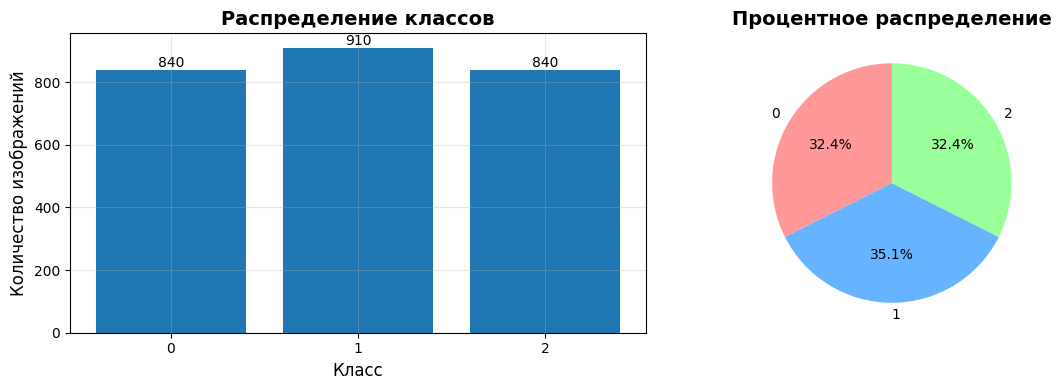

In [ ]:
# визуализация распределения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(class_distribution.index, class_distribution.values)
plt.title('Распределение классов', fontsize=14, fontweight='bold')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество изображений', fontsize=12)
plt.xticks(range(3))
plt.grid(True, alpha=0.3)

# добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
plt.pie(class_distribution.values, labels=class_distribution.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Процентное распределение', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Оценить качество изображений (наличие артефактов, шумов).**

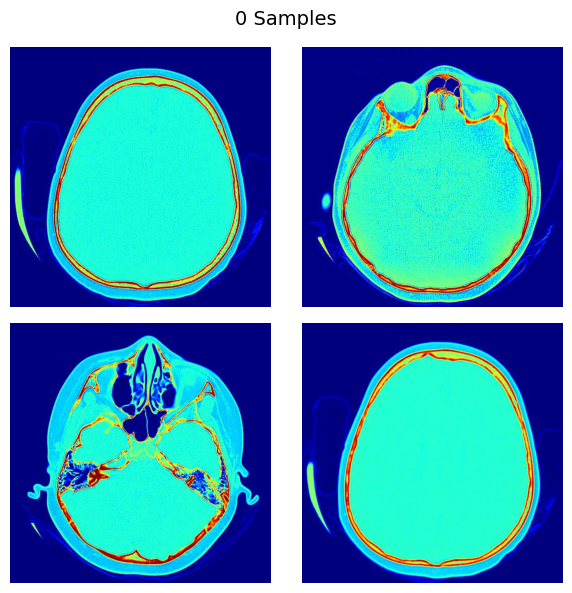

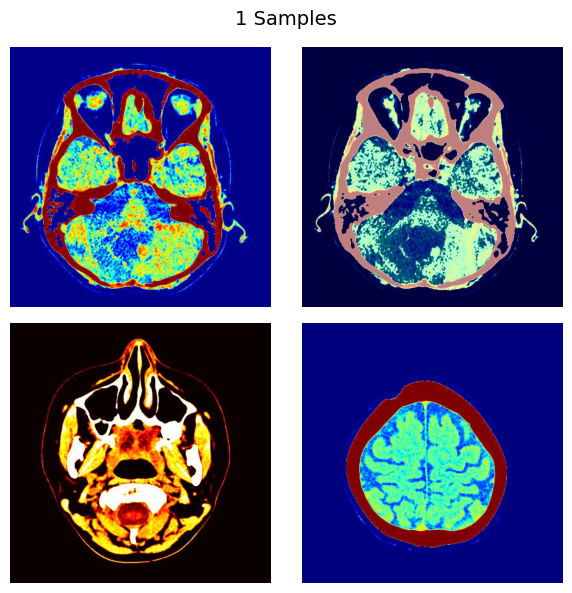

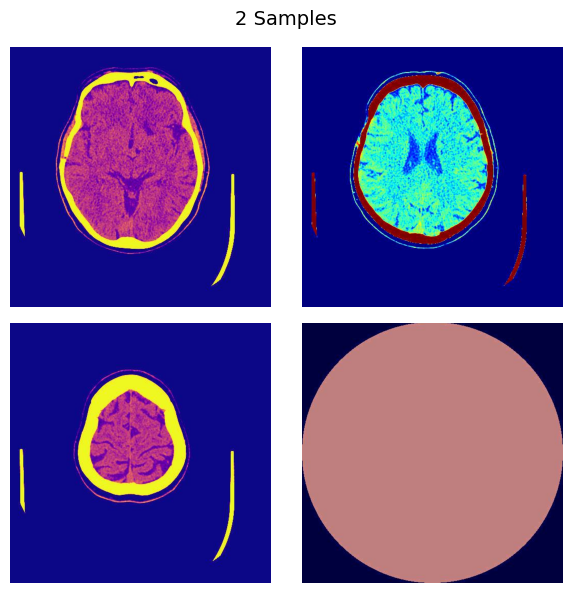

In [ ]:
import random

def plot_random_grid(df, target_class, grid_size=2):

    # Выберем случайные изображения из класса
    samples = df[df['label'] == target_class].sample(grid_size**2)

    # Создание сетки построения графика
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    fig.suptitle(f'{target_class} Samples', fontsize=14)

    for i, ax in enumerate(axes.flat):
        img = Image.open(samples.iloc[i]['path'])
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Построим выборки для каждого класса в наборе данных
for cls in df['label'].unique():
    plot_random_grid(df, cls)

На изображениях присутствуют артефакты и шумы

**2. Выполнить предобработку данных:**

Привести все изображения к единому размеру (рекомендуется 224×224 или 256×256 пикселей).
Нормализовать значения пикселей.
Применить методы увеличения данных (аугментации):
- случайные повороты (в пределах 15 градусов);
- горизонтальное отражение;
- незначительные изменения яркости/контраста.

In [ ]:
import albumentations as A

 Функции предобработки определены
  - preprocess_retina_image - основная функция обработки
  - Поддерживает аугментацию и CLAHE контраст
  Путь к изображениям: /content/drive/MyDrive/dataset/trains
  Пример изображения: /content/drive/MyDrive/dataset/train/tumor/0_1.jpg
  Файл существует: True
 Тест успешен
    Размер изображения: (256, 256, 3)
    Диапазон значений: [0.000, 1.000]
    Тип данных: float32


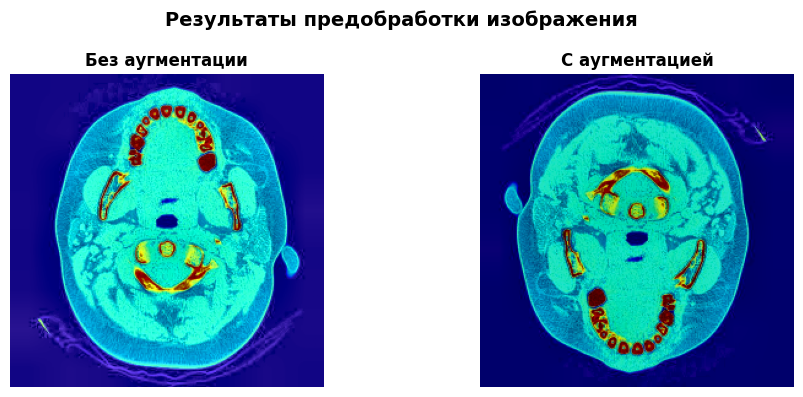

In [ ]:
# функции предобработки изображений

def preprocess_retina_image(image_path, size=256, augment=False):
    """
    Улучшенная предобработка изображений включает удаление черных границ, CLAHE, изменение размера и нормализацию
    """
    # проверка существования файла
    if not os.path.exists(image_path):
        print(f"  ⚠ Файл не найден: {os.path.basename(image_path)}")
        return np.zeros((size, size, 3), dtype=np.float32)

    try:
        # загрузка изображения
        image = cv2.imread(image_path)
        if image is None:
            print(f"  ⚠ Не удалось загрузить: {os.path.basename(image_path)}")
            return np.zeros((size, size, 3), dtype=np.float32)

        # конвертация в RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


        # улучшение контраста с помощью CLAHE
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
        l = clahe.apply(l)

        lab = cv2.merge([l, a, b])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # изменение размера с сохранением пропорций
        h, w = image.shape[:2]
        scale = size / max(h, w)
        new_h, new_w = int(h * scale), int(w * scale)

        image = cv2.resize(image, (new_w, new_h))

        # добавление паддинга для квадрата
        pad_h = (size - new_h) // 2
        pad_w = (size - new_w) // 2

        image = cv2.copyMakeBorder(
            image,
            pad_h, size - new_h - pad_h,
            pad_w, size - new_w - pad_w,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0]
        )

        # нормализация
        image = image.astype(np.float32) / 255.0

        # аугментация (только для тренировочных данных)
        if augment:
            transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.Rotate(limit=15, p=0.5),
                A.RandomBrightnessContrast(
                    brightness_limit=0.1,
                    contrast_limit=0.1,
                    p=0.5
                ),
                A.OneOf([
                    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
                    A.MotionBlur(blur_limit=(3, 7), p=0.3),
                ], p=0.2),
            ])
            image = transform(image=image)['image']

        return image

    except Exception as e:
        print(f"  Ошибка обработки {os.path.basename(image_path)}: {str(e)[:50]}...")
        return np.zeros((size, size, 3), dtype=np.float32)

print(" Функции предобработки определены")
print("  - preprocess_retina_image - основная функция обработки")
print("  - Поддерживает аугментацию и CLAHE контраст")

folder = '/content/drive/MyDrive/dataset/trains'
test_image_path = '/content/drive/MyDrive/dataset/train/tumor/0_1.jpg'

print(f"  Путь к изображениям: {folder}")
print(f"  Пример изображения: {test_image_path}")
print(f"  Файл существует: {os.path.exists(test_image_path)}")


if os.path.exists(test_image_path):
    # обработка без аугментации
    image_no_aug = preprocess_retina_image(test_image_path, augment=False)

    # обработка с аугментацией
    image_aug = preprocess_retina_image(test_image_path, augment=True)

    print(f" Тест успешен")
    print(f"    Размер изображения: {image_no_aug.shape}")
    print(f"    Диапазон значений: [{image_no_aug.min():.3f}, {image_no_aug.max():.3f}]")
    print(f"    Тип данных: {image_no_aug.dtype}")

    # визуализация результатов обработки
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(image_no_aug)
    axes[0].set_title('Без аугментации', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(image_aug)
    axes[1].set_title('С аугментацией', fontweight='bold')
    axes[1].axis('off')

    plt.suptitle('Результаты предобработки изображения', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(" Тестовый файл не найден!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Аугментация для тренировочных данных
train_datagen = ImageDataGenerator(
    rescale=1./255, #фактор масштабирования
    rotation_range=15, #диапазон градусов для случайных поворотов
    width_shift_range=0.1, #диапазон для случайных горизонтальных смещений
    brightness_range=[0.9, 1.1], #диапазон для изменения яркости изображения
    horizontal_flip=True #позволяет случайно переворачивать входные изображения по горизонтали
)

# Только нормализация для тестовых данных
test_datagen = ImageDataGenerator(rescale=1./255)

**3. Разделить данные на:**
- Обучающую выборку (70-80%).
- Валидационную выборку (10-15%).
- Тестовую выборку (10-15%).

 Данные успешно разделены:
  - Тренировочный набор: 2072 изображений (100.0%)
  - Валидационный набор: 518 изображений (25.0%)
Тренировочный набор:
  Класс 0:  840 (40.5%)
  Класс 1:  910 (43.9%)
  Класс 2:  840 (40.5%)

Валидационный набор:
  Класс 0:  168 (32.4%)
  Класс 1:  182 (35.1%)
  Класс 2:  168 (32.4%)


/tmp/ipython-input-2449485053.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = train_class_dist.get(class_id, 0)
/tmp/ipython-input-2449485053.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = val_class_dist.get(class_id, 0)


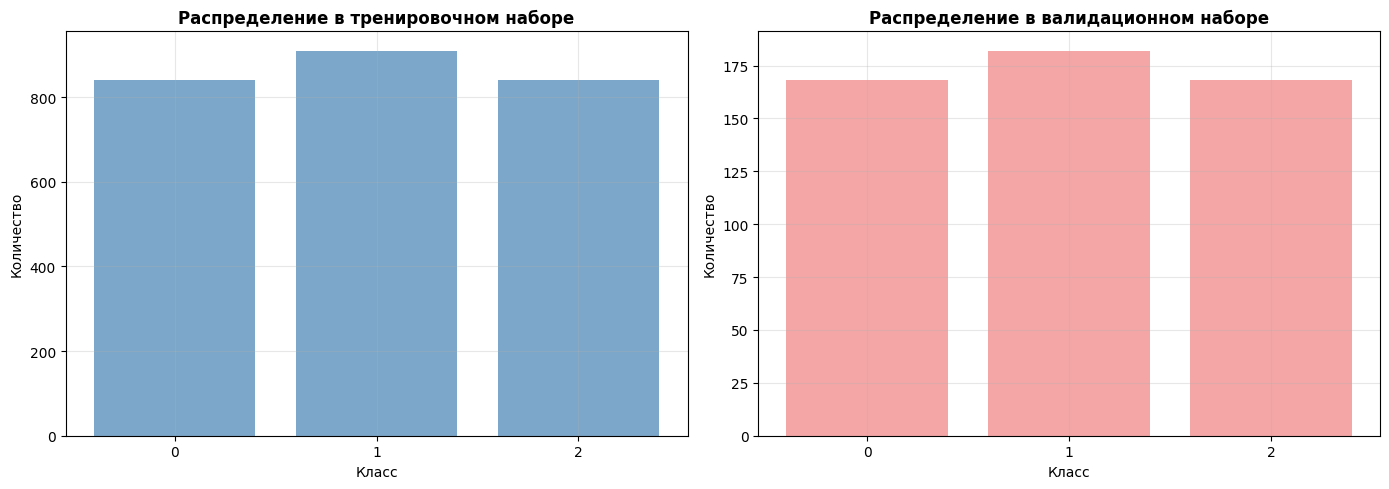

In [ ]:
# разделение данных на train/val

# стратифицированное разделение для сохранения пропорций классов
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

print(f" Данные успешно разделены:")
print(f"  - Тренировочный набор: {len(train_df):3d} изображений ({len(train_df)/len(train_df)*100:.1f}%)")
print(f"  - Валидационный набор: {len(val_df):3d} изображений ({len(val_df)/len(train_df)*100:.1f}%)")

# проверка распределения классов в наборах
print("Тренировочный набор:")
train_class_dist = df['label'].value_counts().sort_index()
for class_id in range(3):
    count = train_class_dist.get(class_id, 0)
    percentage = (count / len(train_df)) * 100
    print(f"  Класс {class_id}: {count:4d} ({percentage:.1f}%)")

print("\nВалидационный набор:")
val_class_dist = val_df['label'].value_counts().sort_index()
for class_id in range(3):
    count = val_class_dist.get(class_id, 0)
    percentage = (count / len(val_df)) * 100
    print(f"  Класс {class_id}: {count:4d} ({percentage:.1f}%)")

#  визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_class_dist.index, train_class_dist.values, color='steelblue', alpha=0.7)
axes[0].set_title('Распределение в тренировочном наборе', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(3))

axes[1].bar(val_class_dist.index, val_class_dist.values, color='lightcoral', alpha=0.7)
axes[1].set_title('Распределение в валидационном наборе', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(3))

plt.tight_layout()
plt.show()

In [ ]:
# Потоки данных
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label",
    target_size=(256, 256),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="label",
    target_size=(256, 256),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 2072 validated image filenames belonging to 3 classes.
Found 518 validated image filenames belonging to 3 classes.


In [ ]:
train_generator

# **2. Построение и обучение модели**

**1. Использовать transfer learning на основе предобученной модели:**

Вариант 1: ResNet18/VGG16 (баланс между точностью и скоростью).

Вариант 2: EfficientNet (высокая точность при меньшем количестве параметров).

**2. Модифицировать последние слои модели для решения конкретной задачи:**
 - Заменить финальный полносвязный слой.
 - Добавить dropout для предотвращения переобучения.

**3. Настроить процесс обучения:**
 - Оптимизатор: Adam с learning rate ~0.001.
 - Функция потерь: CrossEntropyLoss для многоклассовой классификации.
 - Ранняя остановка при переобучении.

**EfficientNet (высокая точность при меньшем количестве параметров).**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks as kcallbacks

In [ ]:
# создание и компиляция модели
def build_model(input_shape=(256, 256, 3)):
    """
    Создание модели для классификации опухолей
    на основе EfficientNetB3 с кастомными слоями
    """

    print(" Строим архитектуру модели...")

    # загрузка предобученной базовой модели
    base_model = tf.keras.applications.EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling=None
    )

    # замораживаем веса базовой модели (на первых эпохах)
    base_model.trainable = False
    print(f"  • Базовая модель: EfficientNetB3")
    print(f"  • Заморожено слоев: {len(base_model.layers)}")

    # создаем кастомные слои
    inputs = tf.keras.Input(shape=input_shape)

    # добавляем аугментацию как часть модели
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomContrast(0.1)(x)

    # предобработка для EfficientNet
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    # пропускаем через базовую модель
    x = base_model(x)

    # глобальный средний пулинг
    x = layers.GlobalAveragePooling2D()(x)

    # регуляризация
    x = layers.Dropout(0.5)(x)

    # полносвязные слои
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # выходной слой
    outputs = layers.Dense(3, activation='softmax')(x)

    # создаем модель
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Classifier")

    print(f"  • Всего слоев в модели: {len(model.layers)}")
    print(f"  • Параметры модели: {model.count_params():,}")

    return model

# создаем модель
print("\n СОЗДАНИЕ МОДЕЛИ:")
model = build_model()

# выводим архитектуру
print("\n АРХИТЕКТУРА МОДЕЛИ:")
model.summary()

# компиляция модели
print("\n КОМПИЛЯЦИЯ МОДЕЛИ:")

# оптимизатор
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# метрики
metrics = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc', multi_label=True),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
]

# компиляция
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=metrics
)

print(" Модель успешно скомпилирована")
print(f"  • Оптимизатор: Adam с CosineDecayRestarts")
print(f"  • Начальный LR: {1e-3}")
print(f"  • Функция потерь: categorical_crossentropy")
print(f"  • Метрики: {len(metrics)} метрик")

# проверка возможности предсказания
print("\n ТЕСТ ПРЕДСКАЗАНИЯ МОДЕЛИ:")
test_input = np.random.randn(2, 256, 256, 3).astype(np.float32)
test_output = model.predict(test_input, verbose=0)

print(f"  • Вход: {test_input.shape}")
print(f"  • Выход: {test_output.shape}")
print(f"  • Сумма вероятностей по классам: {test_output.sum(axis=1)}")
print(" Модель работает корректно")


 СОЗДАНИЕ МОДЕЛИ:
 Строим архитектуру модели...
  • Базовая модель: EfficientNetB3
  • Заморожено слоев: 385
  • Всего слоев в модели: 14
  • Параметры модели: 11,705,650

 АРХИТЕКТУРА МОДЕЛИ:


Model: "Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,705,650 (44.65 MB)

 Trainable params: 920,579 (3.51 MB)

 Non-trainable params: 10,785,071 (41.14 MB)


 КОМПИЛЯЦИЯ МОДЕЛИ:
 Модель успешно скомпилирована
  • Оптимизатор: Adam с CosineDecayRestarts
  • Начальный LR: 0.001
  • Функция потерь: categorical_crossentropy
  • Метрики: 5 метрик

 ТЕСТ ПРЕДСКАЗАНИЯ МОДЕЛИ:
  • Вход: (2, 256, 256, 3)
  • Выход: (2, 3)
  • Сумма вероятностей по классам: [1. 1.]
 Модель работает корректно


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1139s 17s/step - accuracy: 0.3663 - auc: 0.5296 - loss: 2.8035 - precision: 0.3710 - recall: 0.3231 - top_2_accuracy: 0.6835 - val_accuracy: 0.3514 - val_auc: 0.7368 - val_loss: 2.2433 - val_precision: 0.4598 - val_recall: 0.2761 - val_top_2_accuracy: 0.6757
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 769ms/step - accuracy: 0.3886 - auc: 0.5673 - loss: 2.5385 - precision: 0.3956 - recall: 0.3267 - top_2_accuracy: 0.7368 - val_accuracy: 0.3514 - val_auc: 0.6753 - val_loss: 2.1890 - val_precision: 0.4708 - val_recall: 0.2645 - val_top_2_accuracy: 0.7162
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 741ms/step - accuracy: 0.3667 - auc: 0.5348 - loss: 2.4737 - precision: 0.3741 - recall: 0.2768 - top_2_accuracy: 0.6990 - val_accuracy: 0.4035 - val_auc: 0.6803 - val_loss: 2.0821 - val_precision: 0.7031 - val_recall: 0.0869 - val_top_2_accuracy: 0.8031
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 55s 841ms/step - accuracy: 0.3978 - auc: 0.5689 - loss: 2.3060 - precis

# **3. Анализ результатов**

**1. Качественная оценка работы модели:**
- разбор случаев правильной классификации;
- анализ типичных ошибок
- сравнение с базовым уровнем (random guess).

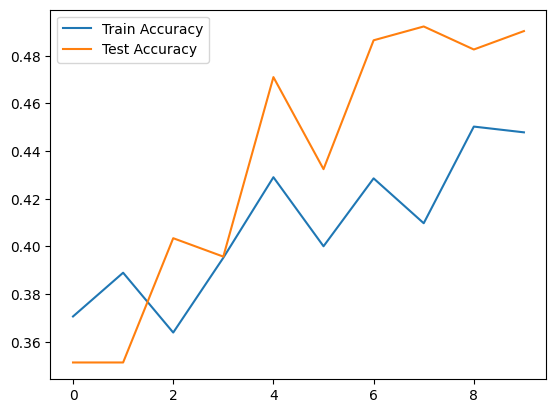

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
test_pred = model.predict(test_generator) # прогнозы на первые 5 тестовых изображений.
test_pred = np.argmax(test_pred, axis=1) # вывод индексов (максимальных значений) для каждого изображения, что и будет искомой меткой.

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_generator.labels, test_pred))

              precision    recall  f1-score   support

           0       0.47      0.83      0.60       168
           1       0.50      0.59      0.54       182
           2       1.00      0.04      0.08       168

    accuracy                           0.49       518
   macro avg       0.66      0.49      0.41       518
weighted avg       0.65      0.49      0.41       518



**2. Визуализация работы модели:**
 - построение heatmap (Grad-CAM) для ключевых случаев;
 - выделение областей, наиболее значимых для принятия решения.

In [ ]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Не найден свёрточный слой!")

last_conv_layer_name = find_last_conv_layer(model)
print(f"Целевой слой: {last_conv_layer_name}")

ValueError: Не найден свёрточный слой!

In [ ]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} ({layer.__class__.__name__})")

0: input_layer_1 (InputLayer)
1: random_flip (RandomFlip)
2: random_rotation (RandomRotation)
3: random_contrast (RandomContrast)
4: efficientnetb3 (Functional)
5: global_average_pooling2d (GlobalAveragePooling2D)
6: dropout (Dropout)
7: dense (Dense)
8: batch_normalization (BatchNormalization)
9: dropout_1 (Dropout)
10: dense_1 (Dense)
11: batch_normalization_1 (BatchNormalization)
12: dropout_2 (Dropout)
13: dense_2 (Dense)


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model.layers[-2]

<Dropout name=dropout_2, built=True>

In [ ]:
model.layers

[<InputLayer name=input_layer_1, built=True>,
 <RandomFlip name=random_flip, built=True>,
 <RandomRotation name=random_rotation, built=True>,
 <RandomContrast name=random_contrast, built=True>,
 <Functional name=efficientnetb3, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_1, built=True>,
 <BatchNormalization name=batch_normalization_1, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_2, built=True>]

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

def grad_cam(img_array, model, last_conv_layer_name="efficientnetb3"):
    # Получаем выход последнего сверточного слоя и предсказание
    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_output, pred = grad_model(img_array)
        pred_index = tf.argmax(pred[0])
        # Записываем градиенты
        tape.watch(conv_output)
        class_channel = pred[:, pred_index]
    grads = tape.gradient(class_channel, conv_output)[0]  # [0] потому что batch=1

    # Создаем heatmap
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.reduce_sum(conv_output[0] * weights, axis=-1)
    heatmap = np.maximum(cam, 0) / (np.max(cam) + 1e-8)
    heatmap = cv2.resize(heatmap, (img_array.shape[2], img_array.shape[1]))
    return heatmap

# Пример для одного изображения
img = next(test_generator)[0][0]
heatmap = grad_cam(np.expand_dims(img,  axis=0), model)
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_385']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m139165337759632\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         ...,\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471]],\n\n        [[0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         ...,\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471]],\n\n        [[0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         ...,\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       , 0.5176471],\n         [0.       , 0.       

In [ ]:
from PIL import Image
import torchvision.transforms as transforms

# Open the image
image = Image.open('/content/drive/MyDrive/dataset/train/tumor/0_9.jpg')

# Define the preprocessing steps
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Preprocess the image
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)

In [ ]:
image

In [ ]:
import torch
import torchvision.models as models

In [ ]:
!pip install torchcam

In [ ]:
import torch
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt

# Initialize Grad-CAM
cam_extractor = GradCAM(model, target_layer=model.features[-1])

# Get the model prediction
with torch.no_grad():
    out = model(input_batch)

# Select the target class (here we take the predicted class)
predicted_class = out.argmax().item()

# Compute the Grad-CAM heatmap
activation_map = cam_extractor(predicted_class, out)

# Overlay the heatmap on the original image
result = overlay_mask(image.convert("RGB"), Image.fromarray(activation_map[0].squeeze().numpy()), alpha=0.5)

# Display the result
plt.imshow(result)
plt.axis('off')
plt.show()

**3. Практические рекомендации:**
 - оценка применимости модели в клинической практике;
 - предложения по улучшению.